# Feature Engineering and Modeling

In [1]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder, FunctionTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from imblearn.ensemble import BalancedRandomForestClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score, recall_score

## Load cleaned data

In [2]:
df = pd.read_csv("../data/processed/train.csv")
df.shape

(243787, 20)

## Train/test split

In [3]:
X = df.drop(columns=["Churn"])
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("Train churn rate:", y_train.mean(), " Test churn rate:", y_test.mean())

Train shape: (195029, 19)  Test shape: (48758, 19)
Train churn rate: 0.18122945818314198  Test churn rate: 0.18124205258624226


In [4]:
df["AccountAge"].describe()
df["AccountAge"].quantile([0.1, 0.25, 0.5])

0.10    13.0
0.25    30.0
0.50    60.0
Name: AccountAge, dtype: float64

In [5]:
from sklearn.base import BaseEstimator, TransformerMixin
import numpy as np

class NewCustomerFlagger(BaseEstimator, TransformerMixin):
    def __init__(self, account_age_col="AccountAge", threshold_months=12, output_col="is_new_customer"):
        self.account_age_col = account_age_col
        self.threshold_months = threshold_months
        self.output_col = output_col

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        X[self.output_col] = np.where(X[self.account_age_col] < self.threshold_months, "Yes", "No")
        return X

    def get_feature_names_out(self, input_features=None):
        input_features = list(input_features) if input_features is not None else []
        return np.array(input_features + [self.output_col])

flagger = NewCustomerFlagger(threshold_months=12)
df = flagger.fit_transform(df)
df["is_new_customer"].value_counts()

is_new_customer
No     221702
Yes     22085
Name: count, dtype: int64

In [6]:
pd.crosstab(df["is_new_customer"], df["Churn"], normalize="index")

from scipy.stats import chi2_contingency
import numpy as np

contingency = pd.crosstab(df["is_new_customer"], df["Churn"])
chi2, p, dof, expected = chi2_contingency(contingency)
n = contingency.sum().sum()
cramers_v = np.sqrt(chi2 / n)
print(f"chi2: {chi2:.2f}, p_value: {p:.10f}, cramers_v: {cramers_v:.4f}")

chi2: 2927.97, p_value: 0.0000000000, cramers_v: 0.1096


In [7]:
df["is_new_customer_binary"] = (df["is_new_customer"] == "Yes").astype(int)
df[["AccountAge", "is_new_customer_binary"]].corr()

,AccountAge,is_new_customer_binary
AccountAge,1.000000,-0.497915
is_new_customer_binary,-0.497915,1.000000


In [11]:
X = df.drop(columns=["Churn"])
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(X_train.columns.tolist())

['AccountAge', 'MonthlyCharges', 'TotalCharges', 'SubscriptionType', 'PaymentMethod', 'PaperlessBilling', 'ContentType', 'MultiDeviceAccess', 'DeviceRegistered', 'ViewingHoursPerWeek', 'AverageViewingDuration', 'ContentDownloadsPerMonth', 'GenrePreference', 'UserRating', 'SupportTicketsPerMonth', 'Gender', 'WatchlistSize', 'ParentalControl', 'SubtitlesEnabled', 'is_new_customer', 'is_new_customer_binary']


In [14]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder

categorical_cols = [
    "SubscriptionType", "PaymentMethod", "ContentType", "GenrePreference",
    "Gender", "ParentalControl", "SubtitlesEnabled", "is_new_customer",
]

numeric_cols_linear = [
    "AccountAge", "MonthlyCharges", "ViewingHoursPerWeek",
    "AverageViewingDuration", "ContentDownloadsPerMonth", "SupportTicketsPerMonth",
]

numeric_cols_tree = numeric_cols_linear + ["UserRating", "WatchlistSize"]

linear_preprocessor = ColumnTransformer(
    transformers=[
        ("scale", StandardScaler(), numeric_cols_linear),
        ("ohe", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
    ],
    remainder="drop",
)

tree_preprocessor = ColumnTransformer(
    transformers=[
        ("ordinal", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1), categorical_cols),
        ("passthrough_num", "passthrough", numeric_cols_tree),
    ],
    remainder="drop",
)

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from imblearn.ensemble import BalancedRandomForestClassifier
from catboost import CatBoostClassifier

linear_pipeline = Pipeline([
    ("preprocess", linear_preprocessor),
    ("clf", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)),
])

rf_pipeline = Pipeline([
    ("preprocess", tree_preprocessor),
    ("clf", RandomForestClassifier(class_weight="balanced", random_state=42)),
])

balanced_rf_pipeline = Pipeline([
    ("preprocess", tree_preprocessor),
    ("clf", BalancedRandomForestClassifier(random_state=42)),
])

catboost_model = CatBoostClassifier(
    cat_features=categorical_cols,
    auto_class_weights="Balanced",
    verbose=0,
    random_state=42,
)

In [19]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {"roc_auc": "roc_auc", "pr_auc": "average_precision", "f1": "f1", "recall": "recall"}

In [17]:
sklearn_models = {
    "logistic_regression": linear_pipeline,
    "random_forest": rf_pipeline,
    "balanced_rf": balanced_rf_pipeline,
}

cv_results = []
for name, model in sklearn_models.items():
    scores = cross_validate(model, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    cv_results.append({
        "model": name,
        "roc_auc": scores["test_roc_auc"].mean(),
        "pr_auc": scores["test_pr_auc"].mean(),
        "f1": scores["test_f1"].mean(),
        "recall": scores["test_recall"].mean(),
    })

In [20]:
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score, recall_score

tree_feature_cols = numeric_cols_tree + categorical_cols
X_train_tree = X_train[tree_feature_cols]

cb_scores = {"roc_auc": [], "pr_auc": [], "f1": [], "recall": []}
for train_idx, val_idx in cv.split(X_train_tree, y_train):
    X_tr, X_val = X_train_tree.iloc[train_idx], X_train_tree.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    cb = CatBoostClassifier(
        cat_features=categorical_cols, auto_class_weights="Balanced", verbose=0, random_state=42,
    )
    cb.fit(X_tr, y_tr)
    proba = cb.predict_proba(X_val)[:, 1]
    preds = cb.predict(X_val)

    cb_scores["roc_auc"].append(roc_auc_score(y_val, proba))
    cb_scores["pr_auc"].append(average_precision_score(y_val, proba))
    cb_scores["f1"].append(f1_score(y_val, preds))
    cb_scores["recall"].append(recall_score(y_val, preds))

In [21]:
cv_results.append({
    "model": "catboost",
    "roc_auc": np.mean(cb_scores["roc_auc"]),
    "pr_auc": np.mean(cb_scores["pr_auc"]),
    "f1": np.mean(cb_scores["f1"]),
    "recall": np.mean(cb_scores["recall"]),
})

In [22]:
pd.set_option("display.float_format", lambda x: f"{x:.4f}")
results_df = pd.DataFrame(cv_results).sort_values("pr_auc", ascending=False).reset_index(drop=True)
results_df

,model,roc_auc,pr_auc,f1,recall
0,logistic_regression,0.7480,0.4004,0.4376,0.6913
1,catboost,0.7418,0.3927,0.4347,0.6710
2,balanced_rf,0.7343,0.3728,0.4245,0.5147
3,random_forest,0.7268,0.3666,0.1087,0.0602


In [23]:
from sklearn.model_selection import cross_val_predict

rf_proba = cross_val_predict(rf_pipeline, X_train, y_train, cv=cv, method="predict_proba", n_jobs=-1)[:, 1]

print("RF predicted probability stats:")
print(pd.Series(rf_proba).describe())
print("\n% of predictions >= 0.5:", (rf_proba >= 0.5).mean() * 100)
print("Actual churn rate:", y_train.mean() * 100)

RF predicted probability stats:
count   195029.0000
mean         0.1750
std          0.1250
min          0.0000
25%          0.0800
50%          0.1500
75%          0.2400
max          0.8500
dtype: float64

% of predictions >= 0.5: 2.190443472509217
Actual churn rate: 18.1229458183142


In [28]:
rf = rf_pipeline
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

print("Test ROC-AUC:", roc_auc_score(y_test, y_proba_rf))
print("Test PR-AUC:", average_precision_score(y_test, y_proba_rf))
print("Test F1:", f1_score(y_test, y_pred_rf))
print("Test recall:", recall_score(y_test, y_pred_rf))

Test ROC-AUC: 0.7317800199810153
Test PR-AUC: 0.37163516564359445
Test F1: 0.11074852131348155
Test recall: 0.06144619214665611


In [ ]:
lr = linear_pipeline
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)
y_proba = lr.predict_proba(X_test)[:, 1]

print("Test ROC-AUC:", roc_auc_score(y_test, y_proba))
print("Test PR-AUC:", average_precision_score(y_test, y_proba))
print("Test F1:", f1_score(y_test, y_pred))
print("Test recall:", recall_score(y_test, y_pred))

In [27]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.68      0.78     39921
           1       0.32      0.70      0.44      8837

    accuracy                           0.68     48758
   macro avg       0.62      0.69      0.61     48758
weighted avg       0.80      0.68      0.71     48758



In [34]:
threshold = 0.33
y_proba_rf = rf.predict_proba(X_test)[:, 1]
y_pred_rf = (y_proba_rf > threshold).astype(int)

y_pred_rf

array([0, 0, 0, ..., 0, 0, 0], shape=(48758,))

In [35]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.85      0.92      0.88     39921
           1       0.44      0.29      0.35      8837

    accuracy                           0.80     48758
   macro avg       0.65      0.60      0.62     48758
weighted avg       0.78      0.80      0.79     48758



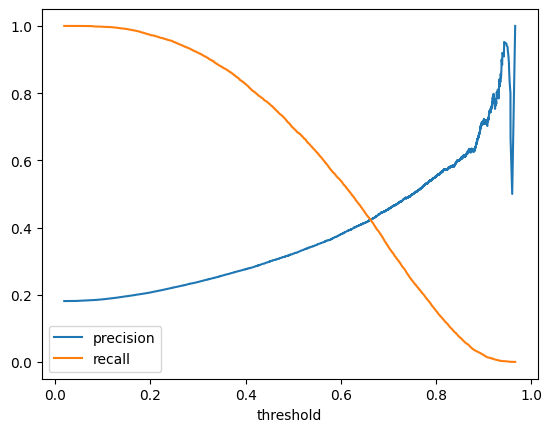

In [36]:
from sklearn.metrics import precision_recall_curve, classification_report

precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)

# plot to see the tradeoff visually
import matplotlib.pyplot as plt
plt.plot(thresholds, precisions[:-1], label="precision")
plt.plot(thresholds, recalls[:-1], label="recall")
plt.xlabel("threshold")
plt.legend()
plt.show()

In [37]:
from sklearn.metrics import precision_score, recall_score, f1_score, fbeta_score

thresholds_to_test = np.arange(0.1, 0.91, 0.05)

threshold_results = []
for t in thresholds_to_test:
    y_pred_t = (y_proba >= t).astype(int)
    threshold_results.append({
        "threshold": round(t, 2),
        "precision": precision_score(y_test, y_pred_t, zero_division=0),
        "recall": recall_score(y_test, y_pred_t),
        "f1": f1_score(y_test, y_pred_t),
        "f0.5": fbeta_score(y_test, y_pred_t, beta=0.5),
    })

threshold_df = pd.DataFrame(threshold_results)
print(threshold_df.to_string(index=False))

best_f1 = threshold_df.loc[threshold_df["f1"].idxmax()]
best_f05 = threshold_df.loc[threshold_df["f0.5"].idxmax()]
print("\nBest by F1 (balanced):")
print(best_f1)
print("\nBest by F0.5 (precision-weighted, matches your stated priority):")
print(best_f05)

 threshold  precision  recall     f1   f0.5
    0.1000     0.1865  0.9974 0.3142 0.2227
    0.1500     0.1956  0.9908 0.3267 0.2330
    0.2000     0.2069  0.9732 0.3412 0.2455
    0.2500     0.2220  0.9518 0.3600 0.2622
    0.3000     0.2381  0.9201 0.3783 0.2795
    0.3500     0.2565  0.8776 0.3969 0.2987
    0.4000     0.2761  0.8264 0.4139 0.3185
    0.4500     0.2987  0.7680 0.4302 0.3403
    0.5000     0.3223  0.6970 0.4408 0.3612
    0.5500     0.3492  0.6233 0.4476 0.3829
    0.6000     0.3798  0.5389 0.4456 0.4037
    0.6500     0.4134  0.4461 0.4291 0.4196
    0.7000     0.4551  0.3428 0.3910 0.4271
    0.7500     0.4981  0.2419 0.3257 0.4111
    0.8000     0.5531  0.1528 0.2394 0.3629
    0.8500     0.6024  0.0736 0.1311 0.2471
    0.9000     0.7160  0.0208 0.0405 0.0933

Best by F1 (balanced):
threshold   0.5500
precision   0.3492
recall      0.6233
f1          0.4476
f0.5        0.3829
Name: 9, dtype: float64

Best by F0.5 (precision-weighted, matches your stated priority):

In [38]:
from sklearn.metrics import classification_report

linear_pipeline_unweighted = Pipeline([
    ("preprocess", linear_preprocessor),
    ("clf", LogisticRegression(max_iter=1000, random_state=42)),
])

linear_pipeline_unweighted.fit(X_train, y_train)
y_proba_unweighted = linear_pipeline_unweighted.predict_proba(X_test)[:, 1]
y_pred_unweighted = linear_pipeline_unweighted.predict(X_test)

print("Default threshold (0.5), no class_weight:")
print(classification_report(y_test, y_pred_unweighted))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_unweighted))
print("PR-AUC:", average_precision_score(y_test, y_proba_unweighted))

Default threshold (0.5), no class_weight:
              precision    recall  f1-score   support

           0       0.83      0.98      0.90     39921
           1       0.57      0.12      0.19      8837

    accuracy                           0.82     48758
   macro avg       0.70      0.55      0.55     48758
weighted avg       0.79      0.82      0.77     48758

ROC-AUC: 0.7538267278962292
PR-AUC: 0.4075940540266461


In [39]:
threshold_results_unweighted = []
for t in thresholds_to_test:
    y_pred_t = (y_proba_unweighted >= t).astype(int)
    threshold_results_unweighted.append({
        "threshold": round(t, 2),
        "precision": precision_score(y_test, y_pred_t, zero_division=0),
        "recall": recall_score(y_test, y_pred_t),
        "f1": f1_score(y_test, y_pred_t),
        "f0.5": fbeta_score(y_test, y_pred_t, beta=0.5),
    })

threshold_df_unweighted = pd.DataFrame(threshold_results_unweighted)
print(threshold_df_unweighted.to_string(index=False))

 threshold  precision  recall     f1   f0.5
    0.1000     0.2498  0.8937 0.3904 0.2918
    0.1500     0.2951  0.7758 0.4276 0.3369
    0.2000     0.3386  0.6521 0.4457 0.3746
    0.2500     0.3810  0.5356 0.4453 0.4044
    0.3000     0.4221  0.4254 0.4237 0.4228
    0.3500     0.4641  0.3214 0.3798 0.4262
    0.4000     0.5017  0.2370 0.3219 0.4101
    0.4500     0.5413  0.1721 0.2612 0.3788
    0.5000     0.5733  0.1172 0.1947 0.3224
    0.5500     0.6018  0.0749 0.1332 0.2501
    0.6000     0.6329  0.0431 0.0807 0.1694
    0.6500     0.7119  0.0243 0.0471 0.1070
    0.7000     0.7537  0.0114 0.0225 0.0539
    0.7500     0.8409  0.0042 0.0083 0.0205
    0.8000     0.9375  0.0017 0.0034 0.0084
    0.8500     1.0000  0.0001 0.0002 0.0006
    0.9000     0.0000  0.0000 0.0000 0.0000


In [40]:
cb_final = CatBoostClassifier(
    cat_features=categorical_cols, auto_class_weights="Balanced", verbose=0, random_state=42,
)
cb_final.fit(X_train[tree_feature_cols], y_train)

y_proba_cb = cb_final.predict_proba(X_test[tree_feature_cols])[:, 1]
y_pred_cb = cb_final.predict(X_test[tree_feature_cols])

print("CatBoost, default threshold (0.5):")
print(classification_report(y_test, y_pred_cb))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_cb))
print("PR-AUC:", average_precision_score(y_test, y_proba_cb))

cb_threshold_results = []
for t in thresholds_to_test:
    y_pred_t = (y_proba_cb >= t).astype(int)
    cb_threshold_results.append({
        "threshold": round(t, 2),
        "precision": precision_score(y_test, y_pred_t, zero_division=0),
        "recall": recall_score(y_test, y_pred_t),
        "f1": f1_score(y_test, y_pred_t),
        "f0.5": fbeta_score(y_test, y_pred_t, beta=0.5),
    })

cb_threshold_df = pd.DataFrame(cb_threshold_results)
print("\nCatBoost threshold sweep:")
print(cb_threshold_df.to_string(index=False))

CatBoost, default threshold (0.5):
              precision    recall  f1-score   support

           0       0.91      0.68      0.77     39921
           1       0.32      0.68      0.43      8837

    accuracy                           0.68     48758
   macro avg       0.61      0.68      0.60     48758
weighted avg       0.80      0.68      0.71     48758

ROC-AUC: 0.7456795718562379
PR-AUC: 0.3997263053924591

CatBoost threshold sweep:
 threshold  precision  recall     f1   f0.5
    0.1000     0.1910  0.9916 0.3203 0.2278
    0.1500     0.2001  0.9788 0.3323 0.2380
    0.2000     0.2121  0.9608 0.3475 0.2513
    0.2500     0.2259  0.9340 0.3639 0.2663
    0.3000     0.2408  0.8982 0.3798 0.2821
    0.3500     0.2574  0.8555 0.3957 0.2992
    0.4000     0.2771  0.8109 0.4130 0.3191
    0.4500     0.2971  0.7539 0.4262 0.3381
    0.5000     0.3179  0.6837 0.4341 0.3560
    0.5500     0.3445  0.6124 0.4409 0.3775
    0.6000     0.3736  0.5333 0.4394 0.3974
    0.6500     0.4111  0.445

In [41]:
importances = pd.Series(cb_final.get_feature_importance(), index=tree_feature_cols).sort_values(ascending=False)
print(importances)

AccountAge                 17.9230
AverageViewingDuration     16.9288
ViewingHoursPerWeek        14.4979
ContentDownloadsPerMonth   12.2117
MonthlyCharges             12.0787
UserRating                  9.6998
SupportTicketsPerMonth      5.8865
WatchlistSize               5.5312
SubtitlesEnabled            0.9620
ParentalControl             0.8934
Gender                      0.8781
SubscriptionType            0.6943
GenrePreference             0.6001
PaymentMethod               0.5967
ContentType                 0.3470
is_new_customer             0.2707
dtype: float64


In [42]:
for col in ["UserRating", "WatchlistSize"]:
    bins = pd.qcut(df[col], q=10, duplicates="drop")
    print(f"--- {col} ---")
    print(df.groupby(bins, observed=True)["Churn"].agg(["mean", "count"]))
    print()

--- UserRating ---
                 mean  count
UserRating                  
(0.999, 1.402] 0.1688  24379
(1.402, 1.8]   0.1689  24379
(1.8, 2.203]   0.1757  24378
(2.203, 2.602] 0.1752  24379
(2.602, 3.002] 0.1790  24379
(3.002, 3.404] 0.1856  24378
(3.404, 3.804] 0.1847  24379
(3.804, 4.204] 0.1911  24378
(4.204, 4.604] 0.1898  24379
(4.604, 5.0]   0.1935  24379

--- WatchlistSize ---
                mean  count
WatchlistSize              
(-0.001, 2.0] 0.1681  28945
(2.0, 5.0]    0.1719  29055
(5.0, 7.0]    0.1753  19594
(7.0, 10.0]   0.1756  29346
(10.0, 12.0]  0.1836  19613
(12.0, 15.0]  0.1829  29226
(15.0, 17.0]  0.1893  19805
(17.0, 19.0]  0.1892  19638
(19.0, 22.0]  0.1932  29263
(22.0, 24.0]  0.1901  19302



In [43]:
df["UserRating_x_SupportTickets"] = df["UserRating"] * df["SupportTicketsPerMonth"]
df["WatchlistSize_x_ContentDownloads"] = df["WatchlistSize"] * df["ContentDownloadsPerMonth"]

numeric_cols_linear_v2 = numeric_cols_linear + [
    "UserRating", "WatchlistSize", "UserRating_x_SupportTickets", "WatchlistSize_x_ContentDownloads",
]

linear_preprocessor_v2 = ColumnTransformer(
    transformers=[
        ("scale", StandardScaler(), numeric_cols_linear_v2),
        ("ohe", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
    ],
    remainder="drop",
)

linear_pipeline_v2 = Pipeline([
    ("preprocess", linear_preprocessor_v2),
    ("clf", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)),
])

# rebuild X/y/split so the new columns are present
X = df.drop(columns=["Churn"])
y = df["Churn"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

scores_v2 = cross_validate(linear_pipeline_v2, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
print("logistic_regression_v2 (with UserRating/WatchlistSize + interactions):")
print("roc_auc:", scores_v2["test_roc_auc"].mean())
print("pr_auc:", scores_v2["test_pr_auc"].mean())
print("f1:", scores_v2["test_f1"].mean())
print("recall:", scores_v2["test_recall"].mean())

print("\noriginal logistic_regression (for comparison): roc_auc=0.7480, pr_auc=0.4004, f1=0.4376, recall=0.6913")

logistic_regression_v2 (with UserRating/WatchlistSize + interactions):
roc_auc: 0.7490214997237368
pr_auc: 0.4019441828653597
f1: 0.4380436299904954
recall: 0.6916112604328759

original logistic_regression (for comparison): roc_auc=0.7480, pr_auc=0.4004, f1=0.4376, recall=0.6913


In [44]:
df.head(5).T

,0,1,2,3,4
AccountAge,20,57,73,32,57
MonthlyCharges,11.0552,5.1752,12.1067,7.2637,16.9531
TotalCharges,221.1043,294.9869,883.7860,232.4398,966.3254
SubscriptionType,Premium,Basic,Basic,Basic,Premium
PaymentMethod,Mailed check,Credit card,Mailed check,Electronic check,Electronic check
PaperlessBilling,No,Yes,Yes,No,Yes
ContentType,Both,Movies,Movies,TV Shows,TV Shows
MultiDeviceAccess,No,No,No,No,No
DeviceRegistered,Mobile,Tablet,Computer,Tablet,TV
ViewingHoursPerWeek,36.7581,32.4506,7.3952,27.9604,20.0834


In [45]:
epsilon = 1e-6

# cost-per-engagement: directly operationalizes the "pays more, uses less" churn pattern from EDA
df["cost_per_viewing_hour"] = df["MonthlyCharges"] / (df["ViewingHoursPerWeek"] + epsilon)

# support ticket rate relative to tenure, not raw count
df["support_tickets_per_tenure"] = df["SupportTicketsPerMonth"] / (df["AccountAge"] + epsilon)

# composite engagement score (z-score average of the 3 engagement signals)
for col in ["ViewingHoursPerWeek", "AverageViewingDuration", "ContentDownloadsPerMonth"]:
    df[f"{col}_z"] = (df[col] - df[col].mean()) / df[col].std()
df["engagement_score"] = df[["ViewingHoursPerWeek_z", "AverageViewingDuration_z", "ContentDownloadsPerMonth_z"]].mean(axis=1)
df.drop(columns=["ViewingHoursPerWeek_z", "AverageViewingDuration_z", "ContentDownloadsPerMonth_z"], inplace=True)

new_engineered = ["cost_per_viewing_hour", "support_tickets_per_tenure", "engagement_score"]

# quick sanity check: correlation with Churn
print(df[new_engineered + ["Churn"]].corr()["Churn"])

cost_per_viewing_hour         0.1104
support_tickets_per_tenure    0.1067
engagement_score             -0.2339
Churn                         1.0000
Name: Churn, dtype: float64


In [46]:
numeric_cols_linear_v3 = numeric_cols_linear_v2 + new_engineered
numeric_cols_tree_v3 = numeric_cols_tree + new_engineered
tree_feature_cols_v3 = numeric_cols_tree_v3 + categorical_cols

linear_preprocessor_v3 = ColumnTransformer(
    transformers=[
        ("scale", StandardScaler(), numeric_cols_linear_v3),
        ("ohe", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
    ],
    remainder="drop",
)

linear_pipeline_v3 = Pipeline([
    ("preprocess", linear_preprocessor_v3),
    ("clf", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)),
])

# rebuild X/y/split so new columns are present
X = df.drop(columns=["Churn"])
y = df["Churn"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# --- Logistic Regression CV ---
lr_scores_v3 = cross_validate(linear_pipeline_v3, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
print("logistic_regression_v3 (+ engineered features):")
print("roc_auc:", lr_scores_v3["test_roc_auc"].mean())
print("pr_auc:", lr_scores_v3["test_pr_auc"].mean())
print("f1:", lr_scores_v3["test_f1"].mean())
print("recall:", lr_scores_v3["test_recall"].mean())

# --- CatBoost CV (manual, same as before) ---
X_train_tree_v3 = X_train[tree_feature_cols_v3]
cb_scores_v3 = {"roc_auc": [], "pr_auc": [], "f1": [], "recall": []}
for train_idx, val_idx in cv.split(X_train_tree_v3, y_train):
    X_tr, X_val = X_train_tree_v3.iloc[train_idx], X_train_tree_v3.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    cb = CatBoostClassifier(
        cat_features=categorical_cols, auto_class_weights="Balanced", verbose=0, random_state=42,
    )
    cb.fit(X_tr, y_tr)
    proba = cb.predict_proba(X_val)[:, 1]
    preds = cb.predict(X_val)

    cb_scores_v3["roc_auc"].append(roc_auc_score(y_val, proba))
    cb_scores_v3["pr_auc"].append(average_precision_score(y_val, proba))
    cb_scores_v3["f1"].append(f1_score(y_val, preds))
    cb_scores_v3["recall"].append(recall_score(y_val, preds))

print("\ncatboost_v3 (+ engineered features):")
print("roc_auc:", np.mean(cb_scores_v3["roc_auc"]))
print("pr_auc:", np.mean(cb_scores_v3["pr_auc"]))
print("f1:", np.mean(cb_scores_v3["f1"]))
print("recall:", np.mean(cb_scores_v3["recall"]))

print("\n--- baseline for comparison ---")
print("logistic_regression: roc_auc=0.7480, pr_auc=0.4004, f1=0.4376, recall=0.6913")
print("catboost:             roc_auc=0.7418, pr_auc=0.3927, f1=0.4347, recall=0.6710")

logistic_regression_v3 (+ engineered features):
roc_auc: 0.7490017754032694
pr_auc: 0.4018093502049262
f1: 0.43796673379681944
recall: 0.6915829678879616

catboost_v3 (+ engineered features):
roc_auc: 0.7409551772556082
pr_auc: 0.3921486245263289
f1: 0.43435178329736324
recall: 0.668298203423398

--- baseline for comparison ---
logistic_regression: roc_auc=0.7480, pr_auc=0.4004, f1=0.4376, recall=0.6913
catboost:             roc_auc=0.7418, pr_auc=0.3927, f1=0.4347, recall=0.6710


In [52]:
from sklearn.metrics import confusion_matrix

# --- Business assumptions (PLACEHOLDERS — replace with real company figures before production) ---
customer_value = 500     # estimated value of retaining a customer who would have churned (e.g. avg remaining CLV)
retention_cost = 50      # cost of a retention offer/outreach per flagged customer (discount, contact-center cost, etc.)
save_rate = 0.30         # probability a retention offer actually prevents churn, given the customer was really going to churn

# refit the chosen final model cleanly on current X_train (original feature set — v2/v3 additions didn't help, not used)
final_model = linear_pipeline
final_model.fit(X_train, y_train)
y_proba_final = final_model.predict_proba(X_test)[:, 1]

def business_value(y_true, y_proba, threshold, customer_value, retention_cost, save_rate):
    y_pred = (y_proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    baseline_loss = (tp + fn) * customer_value  # revenue lost to churn if company takes no action at all

    retained_value = tp * save_rate * customer_value      # value saved from successfully-retained true positives
    campaign_cost = (tp + fp) * retention_cost             # cost of running retention offers on everyone flagged
    net_benefit = retained_value - campaign_cost           # profit gained by using the model, vs. no model

    with_model_loss = baseline_loss - net_benefit

    return {
        "threshold": threshold, "tp": tp, "fp": fp, "fn": fn, "tn": tn,
        "baseline_loss_no_model": baseline_loss,
        "net_benefit_with_model": net_benefit,
        "with_model_loss": with_model_loss,
    }

# evaluate at our previously chosen statistical operating point (0.65)
result = business_value(y_test, y_proba_final, threshold=0.70,
                         customer_value=customer_value, retention_cost=retention_cost, save_rate=save_rate)
for k, v in result.items():
    print(f"{k}: {v}")

threshold: 0.7
tp: 3029
fp: 3626
fn: 5808
tn: 36295
baseline_loss_no_model: 4418500
net_benefit_with_model: 121599.99999999994
with_model_loss: 4296900.0


In [48]:
profit_sweep = []
for t in np.arange(0.05, 0.96, 0.05):
    r = business_value(y_test, y_proba_final, threshold=t,
                        customer_value=customer_value, retention_cost=retention_cost, save_rate=save_rate)
    profit_sweep.append(r)

profit_df = pd.DataFrame(profit_sweep)
print(profit_df[["threshold", "tp", "fp", "fn", "net_benefit_with_model"]].to_string(index=False))

best_row = profit_df.loc[profit_df["net_benefit_with_model"].idxmax()]
print("\nProfit-maximizing threshold:")
print(best_row)

 threshold   tp    fp   fn  net_benefit_with_model
    0.0500 8837 39769    0           -1104750.0000
    0.1000 8814 38457   23           -1041450.0000
    0.1500 8756 36006   81            -924700.0000
    0.2000 8600 32975  237            -788750.0000
    0.2500 8411 29479  426            -632850.0000
    0.3000 8131 26021  706            -487950.0000
    0.3500 7755 22484 1082            -348700.0000
    0.4000 7303 19147 1534            -227050.0000
    0.4500 6787 15932 2050            -117900.0000
    0.5000 6159 12949 2678             -31550.0000
    0.5500 5508 10264 3329              37600.0000
    0.6000 4762  7775 4075              87450.0000
    0.6500 3942  5593 4895             114550.0000
    0.7000 3029  3626 5808             121600.0000
    0.7500 2138  2154 6699             106100.0000
    0.8000 1350  1091 7487              80450.0000
    0.8500  650   429 8187              43550.0000
    0.9000  184    73 8653              14750.0000
    0.9500   15     1 8822     

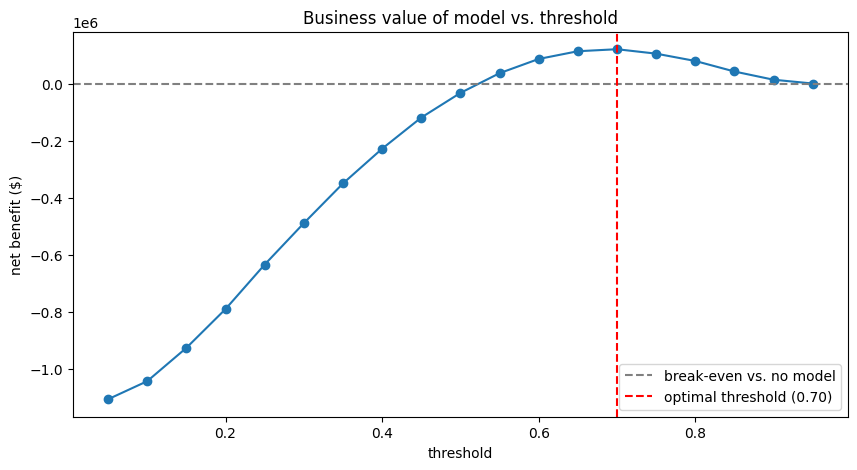

In [49]:
plt.figure(figsize=(10, 5))
plt.plot(profit_df["threshold"], profit_df["net_benefit_with_model"], marker="o")
plt.axhline(0, color="gray", linestyle="--", label="break-even vs. no model")
plt.axvline(best_row["threshold"], color="red", linestyle="--", label=f"optimal threshold ({best_row['threshold']:.2f})")
plt.xlabel("threshold")
plt.ylabel("net benefit ($)")
plt.title("Business value of model vs. threshold")
plt.legend()
plt.show()